# **Beer Data Analysis**

*This data project has been used as a take-home assignment in the recruitment process for the data science positions at Evolent Health.*

## Assignment

In this assignment you will work with a beer data set. Please provide an answer to the questions below. Answer as many questions as possible:

1. Rank the top 3 breweries which produce the strongest beers.
2. Which year did beers enjoy the highest ratings?
3. Based on the users' ratings, which factors are important among taste, aroma, appearance, and palette?
4. If you were to recommend 3 beers to your friends based on this data, which ones would you recommend?
5. Which beer style seems to be the favourite based on the reviews written by users? How does written reviews compare to overall review score for the beer style?

## Data Description

The provided compressed file `BeerDataScienceProject.tar.bz2` contains data about beers and their reviews. It has the following columns:

- `beer_ABV` - alcohol by volume
- `beer_beerId` - beer ID
- `beer_brewerId` - beer brewer ID
- `beer_name` - beer name
- `beer_style` - beer style
- `review_appearance` - review on the beer's appearance
- `review_palette` - review on the beer's palette (colours)
- `review_overall` - overall beer review
- `review_taste` - review on the beer's taste
- `review_profileName` - profile name of the reviewer
- `review_aroma` - review on the beer's aroma
- `review_text` - the full text of the review
- `review_time` - timestamp when the review was made

### Hint

The provided `.tar.bz2` file is a compressed CSV file. Its contents can be loaded to a Pandas DataFrame using the `read_csv()` method from the Pandas library as follows:

```python
df = pd.read_csv("BeerDataScienceProject.tar.bz2", compression="bz2")


## Data Exploration

In [1]:
import pandas as pd
df = pd.read_csv("datasets/BeerDataScienceProject.tar.bz2", compression="bz2", encoding="latin-1")

df.head(10)

,beer_ABV,beer_beerId,beer_brewerId,beer_name,beer_style,review_appearance,review_palette,review_overall,review_taste,review_profileName,review_aroma,review_text,review_time
0,5.0,47986,10325,Sausa Weizen,Hefeweizen,2.5,2.0,1.5,1.5,stcules,1.5,A lot of foam. But a lot. In the smell some ba...,1234817823
1,6.2,48213,10325,Red Moon,English Strong Ale,3.0,2.5,3.0,3.0,stcules,3.0,"Dark red color, light beige foam, average. In ...",1235915097
2,6.5,48215,10325,Black Horse Black Beer,Foreign / Export Stout,3.0,2.5,3.0,3.0,stcules,3.0,"Almost totally black. Beige foam, quite compac...",1235916604
3,5.0,47969,10325,Sausa Pils,German Pilsener,3.5,3.0,3.0,2.5,stcules,3.0,"Golden yellow color. White, compact foam, quit...",1234725145
4,7.7,64883,1075,Cauldron DIPA,American Double / Imperial IPA,4.0,4.5,4.0,4.0,johnmichaelsen,4.5,"According to the website, the style for the Ca...",1293735206
5,4.7,52159,1075,Caldera Ginger Beer,Herbed / Spiced Beer,3.5,3.5,3.0,3.0,oline73,3.5,Poured from the bottle into a Chimay goblet. A...,1325524659
6,4.7,52159,1075,Caldera Ginger Beer,Herbed / Spiced Beer,3.5,3.5,3.5,4.0,Reidrover,4.0,"22 oz bottle from ""Lifesource"" Salem. $3.95 Ni...",1318991115
7,4.7,52159,1075,Caldera Ginger Beer,Herbed / Spiced Beer,3.5,2.5,3.0,2.0,alpinebryant,3.5,"Bottle says ""Malt beverage brewed with Ginger ...",1306276018
8,4.7,52159,1075,Caldera Ginger Beer,Herbed / Spiced Beer,3.5,3.0,4.0,3.5,LordAdmNelson,4.0,I'm not sure why I picked this up... I like gi...,1290454503
9,4.7,52159,1075,Caldera Ginger Beer,Herbed / Spiced Beer,5.0,3.5,4.5,4.0,augustgarage,4.0,Poured from a 22oz bomber into my Drie Fontein...,1285632924


In [2]:
df.shape

(528870, 13)

here are 528,870 rows and 13 columns in the data set. There are two ID columns: beer ID and beer brewer ID. We have the beers' ABV content, the name and style. The rest of the data is related to the beer reviews. We have multiple columns covering different aspects of the reviews: review on specific beers' attributes (aroma, taste, palette, appearance), reviewers' profile, overall grade, the actual text they posted, and the UNIX timestamp when they did that.

The reviews seem to be floats in the range of 1 to 5. Let's check that in the following cell.

In [3]:
df[["review_appearance", "review_palette", "review_overall", "review_taste", "review_aroma"]].describe()

,review_appearance,review_palette,review_overall,review_taste,review_aroma
count,528870.000000,528870.000000,528870.000000,528870.000000,528870.000000
mean,3.864522,3.758926,3.833197,3.765993,3.817350
std,0.604010,0.685335,0.709962,0.669018,0.718903
min,0.000000,1.000000,0.000000,1.000000,1.000000
25%,3.500000,3.500000,3.500000,3.500000,3.500000
50%,4.000000,4.000000,4.000000,4.000000,4.000000
75%,4.000000,4.000000,4.500000,4.000000,4.500000
max,5.000000,5.000000,5.000000,5.000000,5.000000


Our assumptions seem to be correct; though there are some zeros in the overall and appearance reviews. We should probably ignore those, as they look like erroneous data.

In [4]:
df = df[df["review_appearance"] > 0]
df = df[df["review_overall"] > 0]

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 528867 entries, 0 to 528869
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   beer_ABV            508587 non-null  float64
 1   beer_beerId         528867 non-null  int64  
 2   beer_brewerId       528867 non-null  int64  
 3   beer_name           528867 non-null  object 
 4   beer_style          528867 non-null  object 
 5   review_appearance   528867 non-null  float64
 6   review_palette      528867 non-null  float64
 7   review_overall      528867 non-null  float64
 8   review_taste        528867 non-null  float64
 9   review_profileName  528752 non-null  object 
 10  review_aroma        528867 non-null  float64
 11  review_text         528748 non-null  object 
 12  review_time         528867 non-null  int64  
dtypes: float64(6), int64(3), object(4)
memory usage: 56.5+ MB


Looking at the output in the previous cell, we see that different columns have different non-null counts. Easiest solution to deal with it is to drop any row that has a null value by assuming that for that record we have error in collecting the data - the set is mostly complete so this shouldn't be a problem.

In [6]:
df = df.dropna()

In [7]:
df.shape

(508355, 13)

Last thing that we want to do before moving on to answering the question is to deal with the problem of multiple reviews. A user can leave multiple reviews on the same beer, at different times, and this can affect our results. We would like one review per beer / user combination, so we keep only the highest overall review that a user has left for each beer ID.

In [8]:
df = df.sort_values(by="review_overall", ascending=False).drop_duplicates(subset=["review_profileName", "beer_beerId"],
                                                                          keep="first")

In [9]:
df.shape

(503697, 13)

## Question 1

**Rank the top 3 breweries which produce the strongest beers (a beer's strength is determined by its ABV content).**

In [10]:
df_q1 = df.groupby(by=["beer_brewerId"])["beer_ABV"].mean().reset_index().sort_values(by="beer_ABV", ascending=False)
# renaming the column for readability
df_q1 = df_q1.rename(columns={
    "beer_ABV": "mean_brewer_beerABV"
})

In [11]:
df_q1["rank"] = df_q1["mean_brewer_beerABV"].rank(method="dense", ascending=False)
df_q1[df_q1["rank"] <= 3]

,beer_brewerId,mean_brewer_beerABV,rank
699,6513,19.228824,1.0
165,736,13.750000,2.0
1466,24215,12.466667,3.0


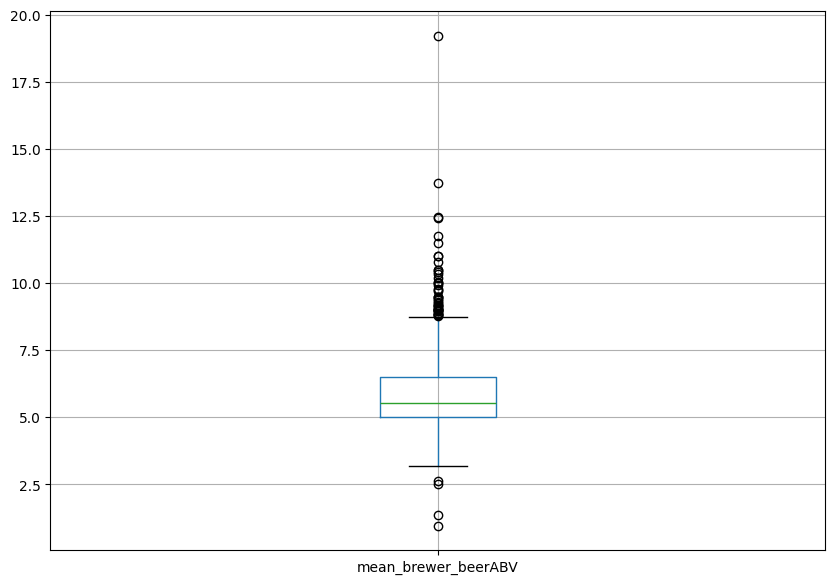

In [12]:
_ = df_q1.boxplot(column="mean_brewer_beerABV", figsize=(10, 7))

## Question 2

**Which year did beers enjoy the highest ratings?**

In [13]:
df["review_year"] = pd.to_datetime(df["review_time"], unit="s").dt.year

Once we have the year, we can aggregate by it and calculate the highest ratings.

As a measure of the "highest ratings in a year" we will take the average overall review for that particular year.

In [14]:
reviews_per_year = df.groupby(by="review_year").size().to_frame("reviews_per_year").reset_index()
# print a sample
reviews_per_year.sample(n=5, random_state=42)

,review_year,reviews_per_year
9,2007,44073
11,2009,80456
0,1998,11
13,2011,107164
5,2003,16304


In [15]:
df_q2 = df.groupby(by="review_year")["review_overall"].mean().reset_index().sort_values(by="review_overall",
                                                                                        ascending=False)
# again, renaming the column for readability
df_q2 = df_q2.rename(columns={
    "review_overall": "yearly_mean_overall_review"
})
df_q2.sample(n=5, random_state=42)

,review_year,yearly_mean_overall_review
13,2011,3.833494
9,2007,3.819697
2,2000,4.241379
6,2004,3.806850
11,2009,3.868500


In [16]:
# merging the two previous DataFrames
df_q2 = df_q2.merge(right=reviews_per_year, how="inner", on="review_year")
df_q2.sample(n=5, random_state=42)

,review_year,yearly_mean_overall_review,reviews_per_year
9,2011,3.833494,107164
11,2007,3.819697,44073
0,2000,4.241379,29
13,2004,3.806850,21038
5,2009,3.868500,80456


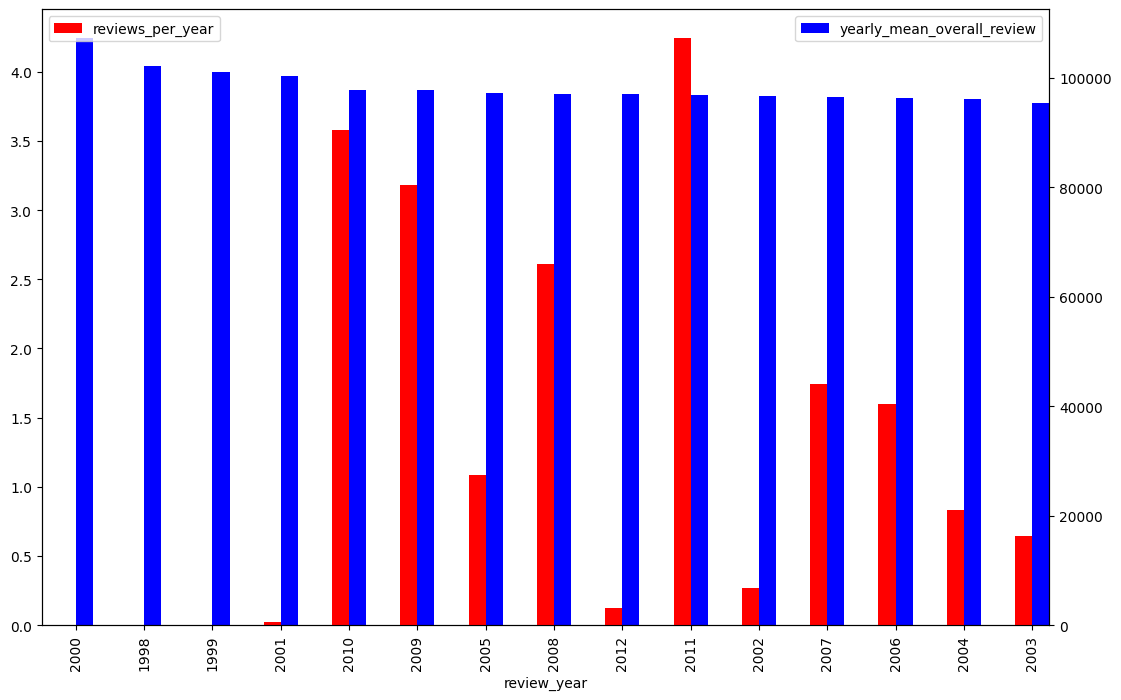

In [17]:
from matplotlib import pyplot as plt

figure = plt.figure(figsize=(13, 8))
ax1 = figure.add_subplot(111)
ax2 = ax1.twinx()
df_q2.plot(x="review_year", y="yearly_mean_overall_review", kind="bar", color="blue", ax=ax1, width=0.25, position=0)
df_q2.plot(x="review_year", y="reviews_per_year", kind="bar", color="red", ax=ax2, width=0.25, position=1)
plt.legend(loc="upper left")
plt.show()

The year ```2000``` is then we got the highest overall reviews of the beers. However, the number of reviews for the top 4 years (ranked by the mean yearly review grade - the blue bars) is very small, so much so that we'd be fine by just ignoring them and marking them as "not having enough data to draw a conclusion". Therefore, the final answer to the question would be the year ```2010```. As an additional observation - the year ```2011``` has the largest number of reviews, and only slightly lower average review grade.

## Question 3

**Based on the users' ratings, which factors are important among taste, aroma, appearance, and palette?**

To determine the importance between the factors listed, and the users' (overall) ratings, we can calculate the correlation coefficient between them and use it as an importance measure.

In [18]:
df_q3 = df.groupby(by="beer_beerId")[[
    "review_taste",
    "review_aroma",
    "review_appearance",
    "review_palette",
    "review_overall"
]].mean()

df_q3.corr()

,review_taste,review_aroma,review_appearance,review_palette,review_overall
review_taste,1.000000,0.835088,0.682127,0.756303,0.823181
review_aroma,0.835088,1.000000,0.660223,0.825980,0.883871
review_appearance,0.682127,0.660223,1.000000,0.669148,0.637575
review_palette,0.756303,0.825980,0.669148,1.000000,0.766908
review_overall,0.823181,0.883871,0.637575,0.766908,1.000000


**Higher correlation = higher importance**. According to the cell output, the aroma is the most important factor for the beer, having a 0.88 correlation with the overall review grade, followed closely by the taste and the palette. The appearance is the least important, but still, has a high correlation coefficient.

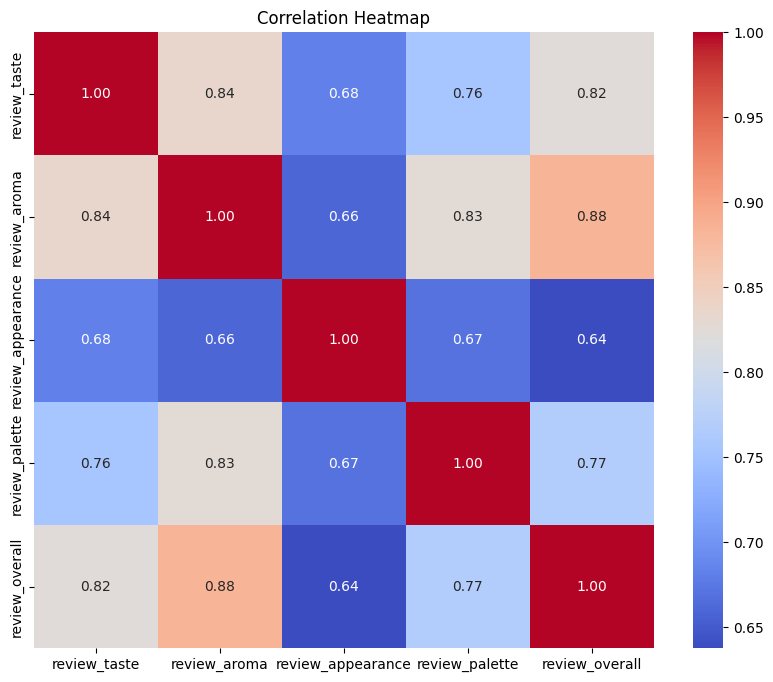

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the heatmap
plt.figure(figsize=(10, 8))  # Adjust figure size for better visibility
sns.heatmap(df_q3.corr(), annot=True, cmap='coolwarm', fmt=".2f")

# Display the plot
plt.title("Correlation Heatmap")
plt.show()

## Question 4

**If you were to recommend 3 beers to your friends based on this data, which ones would you recommend?**

If we were to recommend beers to our friends, based on this data set only, we would like to recommend them the ones that are reviewed most often, and most highly.

In [20]:
df_q4 = df.groupby(by="beer_beerId")["review_overall"].agg(["count", "mean"])

df_q4 = df_q4.rename(columns={
    "count": "num_reviews",
    "mean": "mean_overall_review"
})

Let's sort the beers by their average grade, and see how the top 10 perform.

In [21]:
df_q4.sort_values(by="mean_overall_review", ascending=False, inplace=True)
df_q4.head(n=10)

,num_reviews,mean_overall_review
beer_beerId,,
67283,1,5.0
11895,1,5.0
13222,1,5.0
62145,1,5.0
38766,1,5.0
51454,2,5.0
61988,1,5.0
72809,1,5.0
12413,1,5.0


While their grade is perfect, these beers have only been reviewed once / by a single user; and the opinions are too subjective. We would want to recommend beers that are accepted by a broader number of people, i.e., beers that are enjoyed by a larger audience.

Let's do a little investigation in the distribution of the number of reviews per beer, and see which number would be a proper cut-off.

In [22]:
df_q4.describe()

,num_reviews,mean_overall_review
count,14990.000000,14990.000000
mean,33.602201,3.651688
std,140.888150,0.625075
min,1.000000,1.000000
25%,1.000000,3.400000
50%,3.000000,3.750000
75%,10.000000,4.000000
max,2928.000000,5.000000


The distribution of reviews seems very skewed. Over 50% of beers have less than 3 reviews. Let's plot it and get an even better understanding.

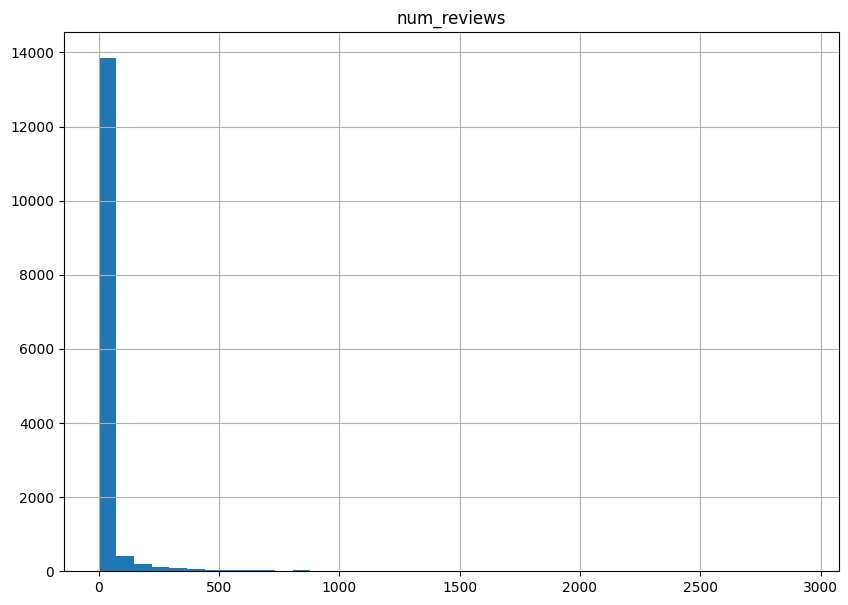

In [23]:
_ = df_q4.hist(column="num_reviews", bins=40, figsize=(10, 7))
plt.show()
plt.close()

As expected, a huge spike is noticed in the lowest bucket. Empirically, we choose 200 reviews as a cut-off point above which we will recommend beers. That's how much we care about our friends. Change the number appropriately for your friends and compare the results.

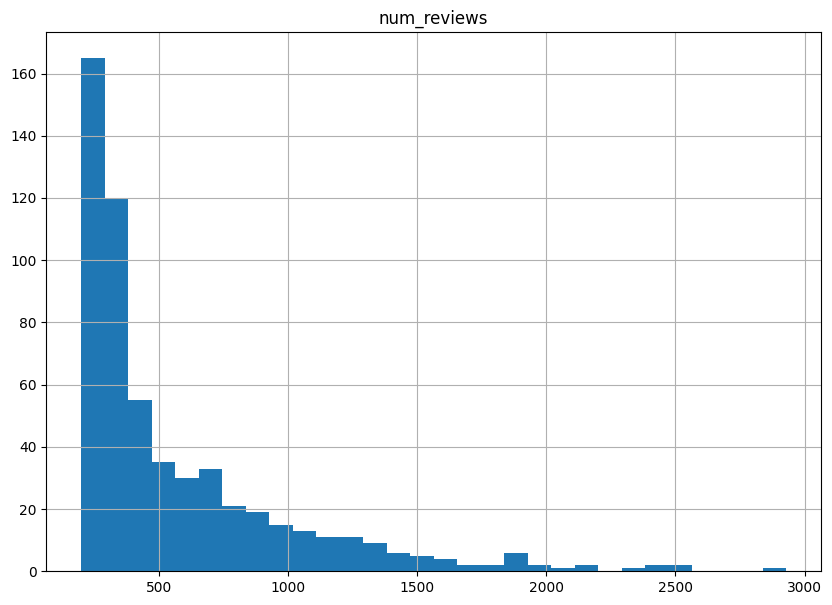

In [24]:
_ = df_q4[df_q4["num_reviews"] > 200].hist(column="num_reviews", bins=30, figsize=(10, 7))
plt.show()
plt.close()

In [25]:
df_q4[df_q4["num_reviews"] > 200].head()

,num_reviews,mean_overall_review
beer_beerId,,
56082,246,4.630081
16814,443,4.623025
47658,618,4.597087
6368,627,4.491228
2899,281,4.437722


In [26]:
df[(df["beer_beerId"] == 56082) | (df["beer_beerId"] == 47658) | (df["beer_beerId"] == 16814)].drop_duplicates(
    subset="beer_beerId")

,beer_ABV,beer_beerId,beer_brewerId,beer_name,beer_style,review_appearance,review_palette,review_overall,review_taste,review_profileName,review_aroma,review_text,review_time,review_year
335037,8.0,56082,14064,Citra DIPA,American Double / Imperial IPA,4.5,5.0,5.0,5.0,OTB,5.0,I was fortunate to get two fresh bottles this ...,1322876922,2011
378616,8.0,16814,27039,Heady Topper,American Double / Imperial IPA,4.0,5.0,5.0,5.0,icepik,5.0,"A : Golden to amber color, large bubbles, some...",1325180700,2011
16698,10.6,47658,1199,Founders CBS Imperial Stout,American Double / Imperial Stout,4.5,4.5,5.0,5.0,treyrab,5.0,"After hearing so much about this beer, a sixte...",1245635836,2009


## Question 5

**Which beer style seems to be the favourite based on the reviews written by users? How does written reviews compare to overall review score for that beer style?**

In the previous questions we have been dealing with statistical matters, but in this question, we have some machine learning involved; natural language processing (NLP) nonetheless.

For the first part of the question, we are going to want to explore the review_text column. It is the text that the user wrote when reviewing the beer. We will use an NLP model that can analyze the sentiment in the text and label it as positive, negative, or neutral.

A suitable solution for this task is the VADER (Valence Aware Dictionary and sEntiment Reasoner) tool.

In [27]:
from nltk import download
from nltk.sentiment.vader import SentimentIntensityAnalyzer

download("vader_lexicon", quiet=True)

analyser = SentimentIntensityAnalyzer()

We create a new column review_sentiment which is the compound score of the review text. Executing this cell will take a few minutes.

In [28]:
df["review_sentiment"] = df["review_text"].apply(lambda x: analyser.polarity_scores(text=x)["compound"])
df.groupby(by="beer_style")["review_sentiment"].agg(func=["mean", "count"]).sort_values(by="mean", ascending=False)

,mean,count
beer_style,,
Quadrupel (Quad),0.857196,4808
Dortmunder / Export Lager,0.855261,1709
Flanders Red Ale,0.852629,2751
Roggenbier,0.850934,137
Braggot,0.850453,197
...,...,...
Happoshu,0.533456,55
American Malt Liquor,0.525378,1332
Japanese Rice Lager,0.514906,488


This output answers the first part of our question - which beer style is most favorite, it is Quadrupel (Quad) (it is furthermore confirmed by a large number of reviews, as shown in the count column). To answer the second part of the question, how the written review compares to the overall review score for the Quadrupel (Quad) style, we can calculate the correlation coefficient between the review sentiment and the overall score. All we can say is that we expect this number to be positive, not necessarily high.

Other styles have scored very close to the first one, with the difference being in the third decimal, and some beers have quite a large number of reviews.

In [29]:
df_q5 = df[df["beer_style"] == "Quadrupel (Quad)"]
df_q5[["review_sentiment", "review_overall"]].corr()

,review_sentiment,review_overall
review_sentiment,1.00000,0.25939
review_overall,0.25939,1.00000


This seems to be the case, as we see a low positive correlation at around 0.26 between the overall review score and the compound score on the review sentiment. Let's check what's happening with the other review attributes.

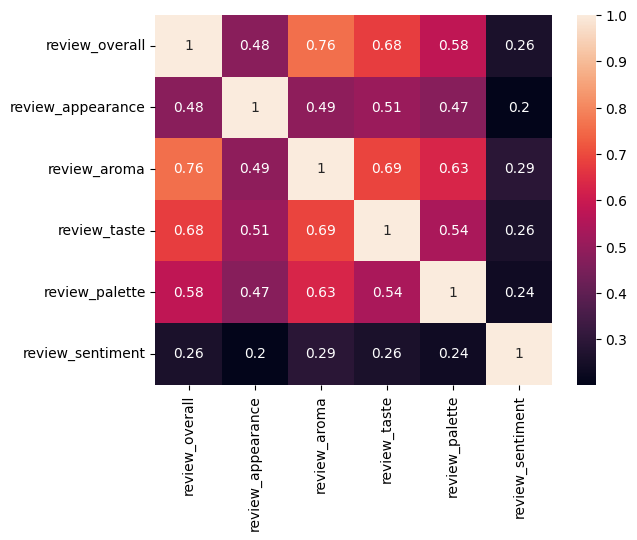

In [31]:
from seaborn import heatmap


_ = heatmap(data=df_q5[[
    "review_overall",
    "review_appearance",
    "review_aroma",
    "review_taste",
    "review_palette",
    "review_sentiment"
]].corr(), annot=True)

plt.show()
plt.close()

All review attributes score similarly, at around 0.2 correlation. This is expected because a single number (the overall review) better expresses the users' opinion of the beer than the written text; that is from the viewpoint of a computer, because the NLP model is not performing at human-level. Moreover, a user could have given a high review of the beer, but leave a rather neutral comment / text. This contributes to the low correlation coefficient. The overall gist is that the coefficient is positive, indicating that increase in the compound score is correlated with an increase in the overall review score.